In [1]:
import os
os.chdir("..") # Ek folder piche jane ke liye
print(os.getcwd()) # Check karein ke ab path 'psl_ai_platform' par hai ya nahi

c:\Users\User\Desktop\psl_ai_platform


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/processed/ball_by_ball/psl_ball_by_ball_with_bowler_type.csv")
df.head()

,match_id,innings_number,batting_team,over,ball,batter,bowler,non_striker,runs_batter,runs_extras,...,city,venue,team1,team2,toss_winner,toss_decision,phase,ball_id,bowling_style,bowler_type
0,959175,1,Islamabad United,0,1,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.1,NaN,Unknown
1,959175,1,Islamabad United,0,2,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.2,NaN,Unknown
2,959175,1,Islamabad United,0,3,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.3,NaN,Unknown
3,959175,1,Islamabad United,0,4,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.4,NaN,Unknown
4,959175,1,Islamabad United,0,5,NaN,Anwar Ali,Sharjeel Khan,0,0,...,NaN,Dubai International Cricket Stadium,Islamabad United,Quetta Gladiators,Quetta Gladiators,field,powerplay,0.5,NaN,Unknown


In [4]:
df["bowler_type"].value_counts(dropna=False)

bowler_type
Unknown              70066
Leg-spin              2781
Left-arm pace         2084
Left-arm orthodox     2049
Right-arm pace        1680
Name: count, dtype: int64

In [5]:
summary = (
    df.groupby(["batter", "bowler_type"])
    .agg(
        balls_faced=("batter", "count"),
        runs_scored=("runs_batter", "sum"),
        dismissals=("player_out", lambda x: x.notna().sum()),
    )
    .reset_index()
)

summary["strike_rate"] = (
    summary["runs_scored"] / summary["balls_faced"] * 100
).round(2)

summary["dismissal_rate"] = (
    summary["dismissals"] / summary["balls_faced"]
).round(4)

summary.head()

,batter,bowler_type,balls_faced,runs_scored,dismissals,strike_rate,dismissal_rate


In [6]:
selected_batters = ["Babar Azam", "Mohammad Rizwan", "Fakhar Zaman"]
selected_df = summary[summary["batter"].isin(selected_batters)]
selected_df

,batter,bowler_type,balls_faced,runs_scored,dismissals,strike_rate,dismissal_rate


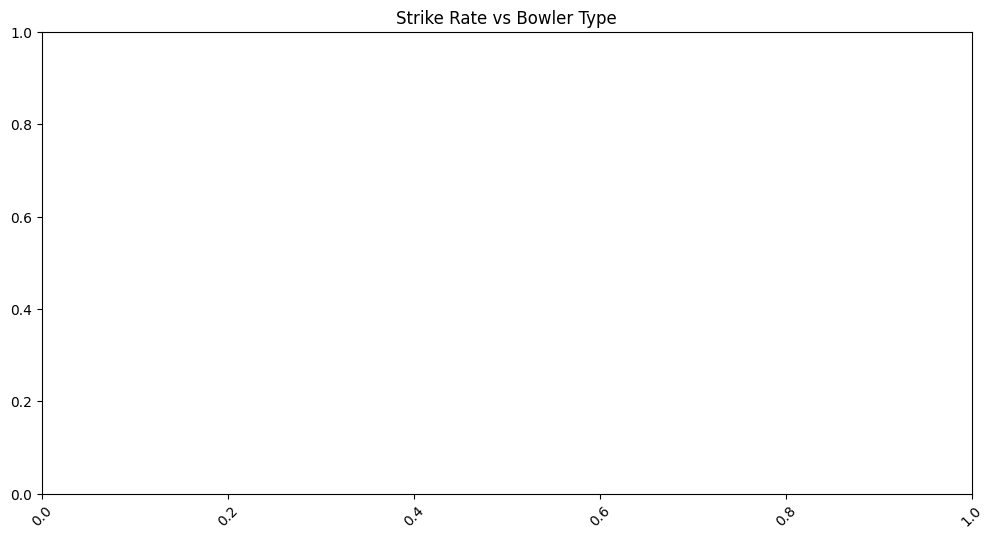

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(data=selected_df, x="bowler_type", y="strike_rate", hue="batter")
plt.xticks(rotation=45)
plt.title("Strike Rate vs Bowler Type")
plt.show()

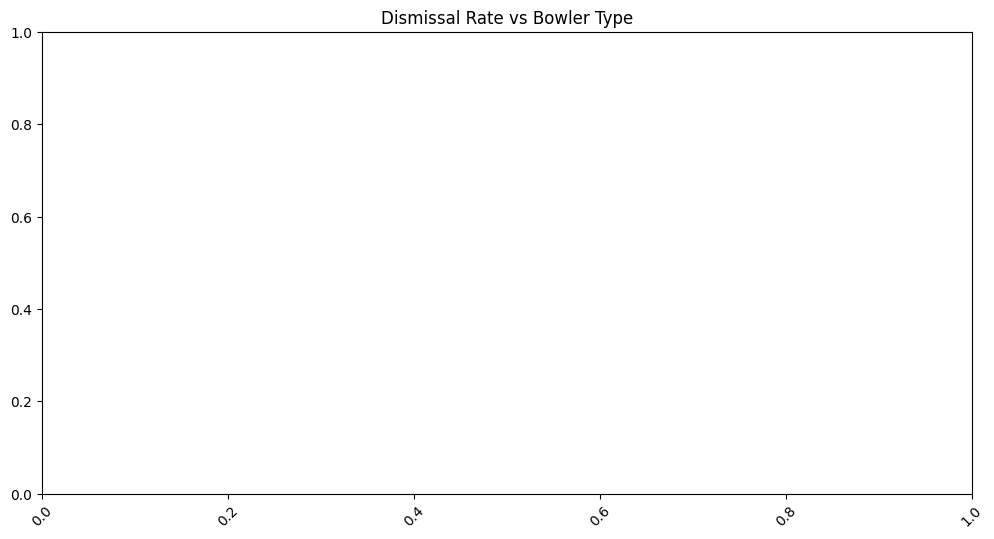

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(data=selected_df, x="bowler_type", y="dismissal_rate", hue="batter")
plt.xticks(rotation=45)
plt.title("Dismissal Rate vs Bowler Type")
plt.show()